In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import preprocessing
import seaborn as sb

In [2]:
data = pd.HDFStore('bdv-data.h5')
print(data.keys())
df = data['gifi8_four_classification']
# pd.read_csv('all_nine_years_regression_format.csv')

['/all_nine_years', '/flat', '/gifi', '/gifi8_four_classification']


In [3]:
df.head()

total_assets_less_cur._liab._th_gbp  net_assets_th_gbp  \
bv_id      year                                                           
GB07114838 2011                               -0.505             -0.505   
           2012                               -2.561             -2.561   
           2013                                7.658              7.658   
           2014                               21.344             21.344   
           2015                               61.440             19.280   

                 net_tangible_assets_(liab.)_th_gbp  total_assets_th_gbp  \
bv_id      year                                                            
GB07114838 2011                              -0.505               32.892   
           2012                              -2.561               33.273   
           2013                               7.658               59.282   
           2014                              21.344               66.893   
           2015                              61.440               61.440   

                 net_current_assets_(working_capital)_th_gbp  \
bv_id      year                                                
GB07114838 2011                                       -0.505   
           2012                                       -2.561   
           2013                                        7.658   
           2014                                       16.693   
           2015                                       57.417   

                 shareholders_funds_th_gbp  current_assets_th_gbp  \
bv_id      year                                                     
GB07114838 2011                     -0.505                 32.892   
           2012                     -2.561                 33.273   
           2013                      7.658                 59.282   
           2014                     21.344                 62.242   
           2015                     19.280                 57.417   

                 total_reserves_th_gbp  current_liabilities_th_gbp  \
bv_id      year                                                      
GB07114838 2011                 -0.506                     -33.397   
           2012                 -2.562                     -35.834   
           2013                  7.657                     -51.624   
           2014                 21.343                     -45.549   
           2015                 19.279                         NaN   

                 solvency_ratio_(asset_based)_(%)  ...  \
bv_id      year                                    ...   
GB07114838 2011                         -1.535328  ...   
           2012                         -7.696931  ...   
           2013                         12.917918  ...   
           2014                         31.907673  ...   
           2015                         31.380208  ...   

                 other_income_pre_gp_th_gbp  other_auditors_services_th_gbp  \
bv_id      year                                                               
GB07114838 2011                         NaN                             NaN   
           2012                         NaN                             NaN   
           2013                         NaN                             NaN   
           2014                         NaN                             NaN   
           2015                         NaN                             NaN   

                 costs_of_reorganisation_th_gbp  \
bv_id      year                                   
GB07114838 2011                             NaN   
           2012                             NaN   
           2013                             NaN   
           2014                             NaN   
           2015                             NaN   

                 non-audit_fees_paid_to_other_auditors_th_gbp  \
bv_id      year                                                 
GB07114838 2011                                           NaN   
           2012     

In [4]:
df.shape

(56584, 181)

In [5]:
col_names = df.columns
col_names

Index(['total_assets_less_cur._liab._th_gbp', 'net_assets_th_gbp',
       'net_tangible_assets_(liab.)_th_gbp', 'total_assets_th_gbp',
       'net_current_assets_(working_capital)_th_gbp',
       'shareholders_funds_th_gbp', 'current_assets_th_gbp',
       'total_reserves_th_gbp', 'current_liabilities_th_gbp',
       'solvency_ratio_(asset_based)_(%)',
       ...
       'other_income_pre_gp_th_gbp', 'other_auditors_services_th_gbp',
       'costs_of_reorganisation_th_gbp',
       'non-audit_fees_paid_to_other_auditors_th_gbp',
       'exceptional_items_pre_gp_th_gbp',
       'profit_(loss)_on_sale_of_operations_th_gbp',
       'UP_solvency_ratio_(asset_based)_(%)',
       'UP_solvency_ratio_(liability_based)_(%)', 'UP_liquidity_ratio_(x)',
       'UP_shareholders_liquidity_ratio_(x)'],
      dtype='object', length=181)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 56584 entries, ('GB07114838', 2011) to ('IE499325', 2018)
Columns: 181 entries, total_assets_less_cur._liab._th_gbp to UP_shareholders_liquidity_ratio_(x)
dtypes: bool(4), float64(177)
memory usage: 77.2+ MB


In [7]:
df[['solvency_ratio_(asset_based)_(%)','UP_solvency_ratio_(asset_based)_(%)']].head(40)

solvency_ratio_(asset_based)_(%)  \
bv_id      year                                     
GB07114838 2011                         -1.535328   
           2012                         -7.696931   
           2013                         12.917918   
           2014                         31.907673   
           2015                         31.380208   
           2016                         33.029091   
           2017                         73.326038   
           2018                         56.736293   
GB07114865 2011                        -40.510357   
           2012                               NaN   
           2013                               NaN   
           2014                               NaN   
           2015                         24.112842   
           2016                         78.511089   
           2017                         73.484893   
           2018                         74.963806   
GB07114884 2011                        100.000000   
           2012                        100.000000   
           2013                        -21.543663   
           2014                        -20.364401   
           2015                          1.129300   
           2016                        -17.197208   
           2017                        -95.823919   
           2018                        -50.258051   
GB07114896 2011                        -19.564539   
           2012                         -9.013434   
           2013                        -49.508317   
           2014                        -24.243486   
           2015                        -17.524974   
           2016                        -33.824920   
           2017                         38.764850   
           2018                               NaN   
GB07114911 2011                         24.310552   
           2012                         26.025036   
           2013                         39.088705   
           2014                         90.064201   
           2015                         80.000000   
           2016                         90.862944   
           2017                         96.265405   
           2018                         95.905369   

                 UP_solvency_ratio_(asset_based)_(%)  
bv_id      year                                       
GB07114838 2011                                False  
           2012                                 True  
           2013                                 True  
           2014                                False  
           2015                                 True  
           2016                                 True  
           2017                                False  
           2018                                False  
GB07114865 2011                                False  
           2012                                False  
           2013                                False  
           2014                                False  
           2015                                 True  
           2016                                False  
           2017                                 True  
           2018                                False  
GB07114884 2011                                False  
           2012                                False  
           2013                                 True  
           2014                                 True  
           2015                                False  
           2016                                False  
           2017                                 True  
           2018                                 True  
GB07114896 2011                                 True  
           2012                                False  
           2013                                 True  
           2014                                 True  
           2015                                False  
           2016                                 True  
           2017               

In [8]:
_y = 'UP_solvency_ratio_(asset_based)_(%)'

df.drop(labels=['UP_solvency_ratio_(liability_based)_(%)',
                'UP_liquidity_ratio_(x)',
                'UP_shareholders_liquidity_ratio_(x)',
                'liquidity_ratio_(x)',
                'solvency_ratio_(asset_based)_(%)',
                'solvency_ratio_(liability_based)_(%)',
                'shareholders_liquidity_ratio_(x)']
         ,axis=1, inplace=True )
df.reset_index(drop=True, inplace=True)
df.info()
Y = df.pop(_y)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56584 entries, 0 to 56583
Columns: 174 entries, total_assets_less_cur._liab._th_gbp to UP_solvency_ratio_(asset_based)_(%)
dtypes: bool(1), float64(173)
memory usage: 74.7 MB


In [9]:
Y.describe()


count     56584
unique        2
top       False
freq      33793
Name: UP_solvency_ratio_(asset_based)_(%), dtype: object

In [10]:
df.isnull().sum()

total_assets_less_cur._liab._th_gbp               142
net_assets_th_gbp                                 423
net_tangible_assets_(liab.)_th_gbp                478
total_assets_th_gbp                               604
net_current_assets_(working_capital)_th_gbp       598
                                                ...  
other_auditors_services_th_gbp                  56579
costs_of_reorganisation_th_gbp                  56582
non-audit_fees_paid_to_other_auditors_th_gbp    56584
exceptional_items_pre_gp_th_gbp                 56584
profit_(loss)_on_sale_of_operations_th_gbp      56584
Length: 173, dtype: int64

In [11]:
df1 = df.loc[:, df.isnull().sum() < 0.8*df.shape[0]]

In [12]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56584 entries, 0 to 56583
Data columns (total 41 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   total_assets_less_cur._liab._th_gbp            56442 non-null  float64
 1   net_assets_th_gbp                              56161 non-null  float64
 2   net_tangible_assets_(liab.)_th_gbp             56106 non-null  float64
 3   total_assets_th_gbp                            55980 non-null  float64
 4   net_current_assets_(working_capital)_th_gbp    55986 non-null  float64
 5   shareholders_funds_th_gbp                      54731 non-null  float64
 6   current_assets_th_gbp                          54960 non-null  float64
 7   total_reserves_th_gbp                          50811 non-null  float64
 8   current_liabilities_th_gbp                     49774 non-null  float64
 9   current_ratio_(x)                              483

In [13]:
df2 = df1.loc[:, df1.isnull().sum() < 0.5*df1.shape[0]]

In [14]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56584 entries, 0 to 56583
Data columns (total 20 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   total_assets_less_cur._liab._th_gbp          56442 non-null  float64
 1   net_assets_th_gbp                            56161 non-null  float64
 2   net_tangible_assets_(liab.)_th_gbp           56106 non-null  float64
 3   total_assets_th_gbp                          55980 non-null  float64
 4   net_current_assets_(working_capital)_th_gbp  55986 non-null  float64
 5   shareholders_funds_th_gbp                    54731 non-null  float64
 6   current_assets_th_gbp                        54960 non-null  float64
 7   total_reserves_th_gbp                        50811 non-null  float64
 8   current_liabilities_th_gbp                   49774 non-null  float64
 9   current_ratio_(x)                            48348 non-null  float64
 10

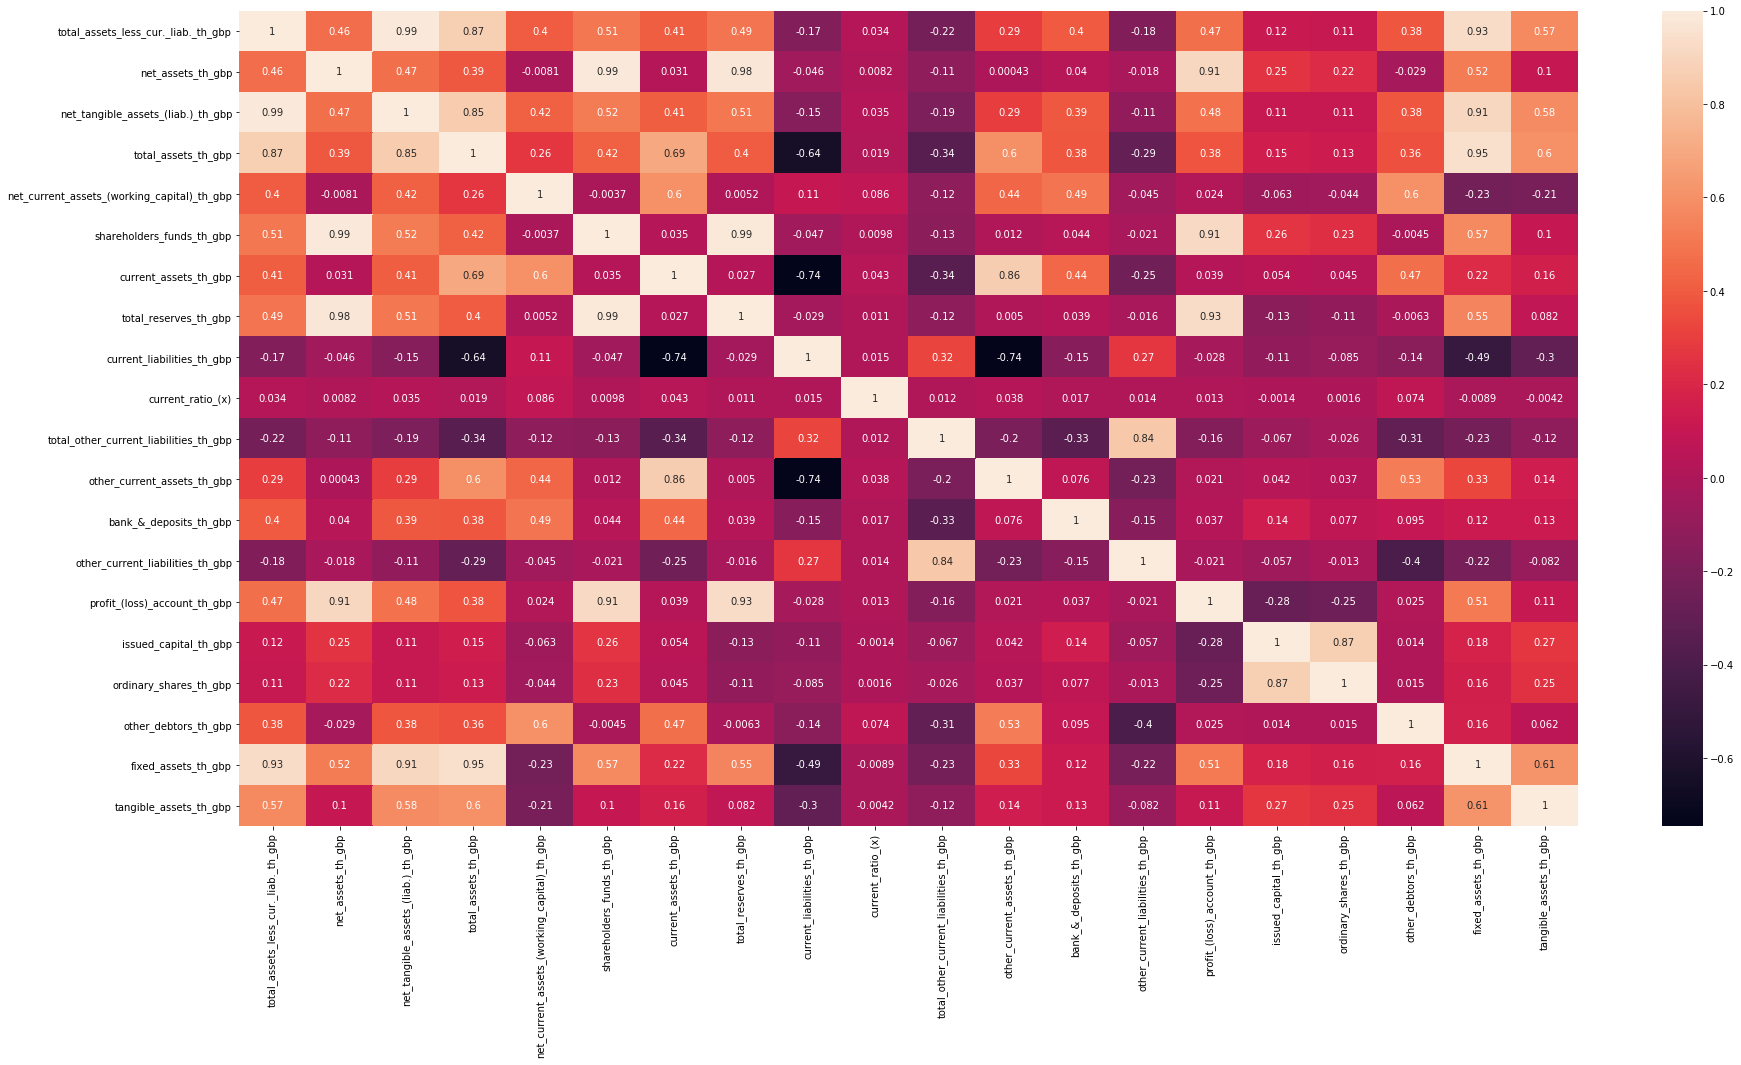

In [15]:
plt.subplots(figsize=(30,15))
sb.heatmap(df2.corr(), annot = True,)

In [16]:
Q1 = df2.quantile(0.25)
Q3 = df2.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

total_assets_less_cur._liab._th_gbp            22.400750
net_assets_th_gbp                              10.965000
net_tangible_assets_(liab.)_th_gbp             20.812500
total_assets_th_gbp                            72.620750
net_current_assets_(working_capital)_th_gbp    13.107000
shareholders_funds_th_gbp                      11.713000
current_assets_th_gbp                          49.472500
total_reserves_th_gbp                          13.686500
current_liabilities_th_gbp                     48.534500
current_ratio_(x)                               1.254402
total_other_current_liabilities_th_gbp         36.409000
other_current_assets_th_gbp                    30.295500
bank_&_deposits_th_gbp                         23.471000
other_current_liabilities_th_gbp               34.496500
profit_(loss)_account_th_gbp                   12.767500
issued_capital_th_gbp                           0.099000
ordinary_shares_th_gbp                          0.099000
other_debtors_th_gbp           

In [17]:
df2.shape

(56584, 20)

In [18]:
df3 = df2[~((df2 < (Q1 - 1.5 * IQR)) |(df2 > (Q3 + 1.5 * IQR))).any(axis=1)]
print(df3.shape)

(32300, 20)


In [19]:
df3.isnull().sum()

total_assets_less_cur._liab._th_gbp              109
net_assets_th_gbp                                325
net_tangible_assets_(liab.)_th_gbp               350
total_assets_th_gbp                              429
net_current_assets_(working_capital)_th_gbp      501
shareholders_funds_th_gbp                        752
current_assets_th_gbp                           1111
total_reserves_th_gbp                           3949
current_liabilities_th_gbp                      5673
current_ratio_(x)                               6401
total_other_current_liabilities_th_gbp          6481
other_current_assets_th_gbp                    12459
bank_&_deposits_th_gbp                          8392
other_current_liabilities_th_gbp                9910
profit_(loss)_account_th_gbp                    9307
issued_capital_th_gbp                           9047
ordinary_shares_th_gbp                          9100
other_debtors_th_gbp                           13807
fixed_assets_th_gbp                           

In [20]:
Y_ = Y.loc[df3.index]

In [21]:
Y_

0        False
1         True
2         True
3        False
5         True
         ...  
56575    False
56576    False
56577    False
56581    False
56583     True
Name: UP_solvency_ratio_(asset_based)_(%), Length: 32300, dtype: bool

In [22]:
print(df3.shape)
df3.isnull().sum()

(32300, 20)


total_assets_less_cur._liab._th_gbp              109
net_assets_th_gbp                                325
net_tangible_assets_(liab.)_th_gbp               350
total_assets_th_gbp                              429
net_current_assets_(working_capital)_th_gbp      501
shareholders_funds_th_gbp                        752
current_assets_th_gbp                           1111
total_reserves_th_gbp                           3949
current_liabilities_th_gbp                      5673
current_ratio_(x)                               6401
total_other_current_liabilities_th_gbp          6481
other_current_assets_th_gbp                    12459
bank_&_deposits_th_gbp                          8392
other_current_liabilities_th_gbp                9910
profit_(loss)_account_th_gbp                    9307
issued_capital_th_gbp                           9047
ordinary_shares_th_gbp                          9100
other_debtors_th_gbp                           13807
fixed_assets_th_gbp                           

In [23]:
df4 = df3.fillna(df3.mean())

In [24]:
df4.isnull().sum()

total_assets_less_cur._liab._th_gbp            0
net_assets_th_gbp                              0
net_tangible_assets_(liab.)_th_gbp             0
total_assets_th_gbp                            0
net_current_assets_(working_capital)_th_gbp    0
shareholders_funds_th_gbp                      0
current_assets_th_gbp                          0
total_reserves_th_gbp                          0
current_liabilities_th_gbp                     0
current_ratio_(x)                              0
total_other_current_liabilities_th_gbp         0
other_current_assets_th_gbp                    0
bank_&_deposits_th_gbp                         0
other_current_liabilities_th_gbp               0
profit_(loss)_account_th_gbp                   0
issued_capital_th_gbp                          0
ordinary_shares_th_gbp                         0
other_debtors_th_gbp                           0
fixed_assets_th_gbp                            0
tangible_assets_th_gbp                         0
dtype: int64

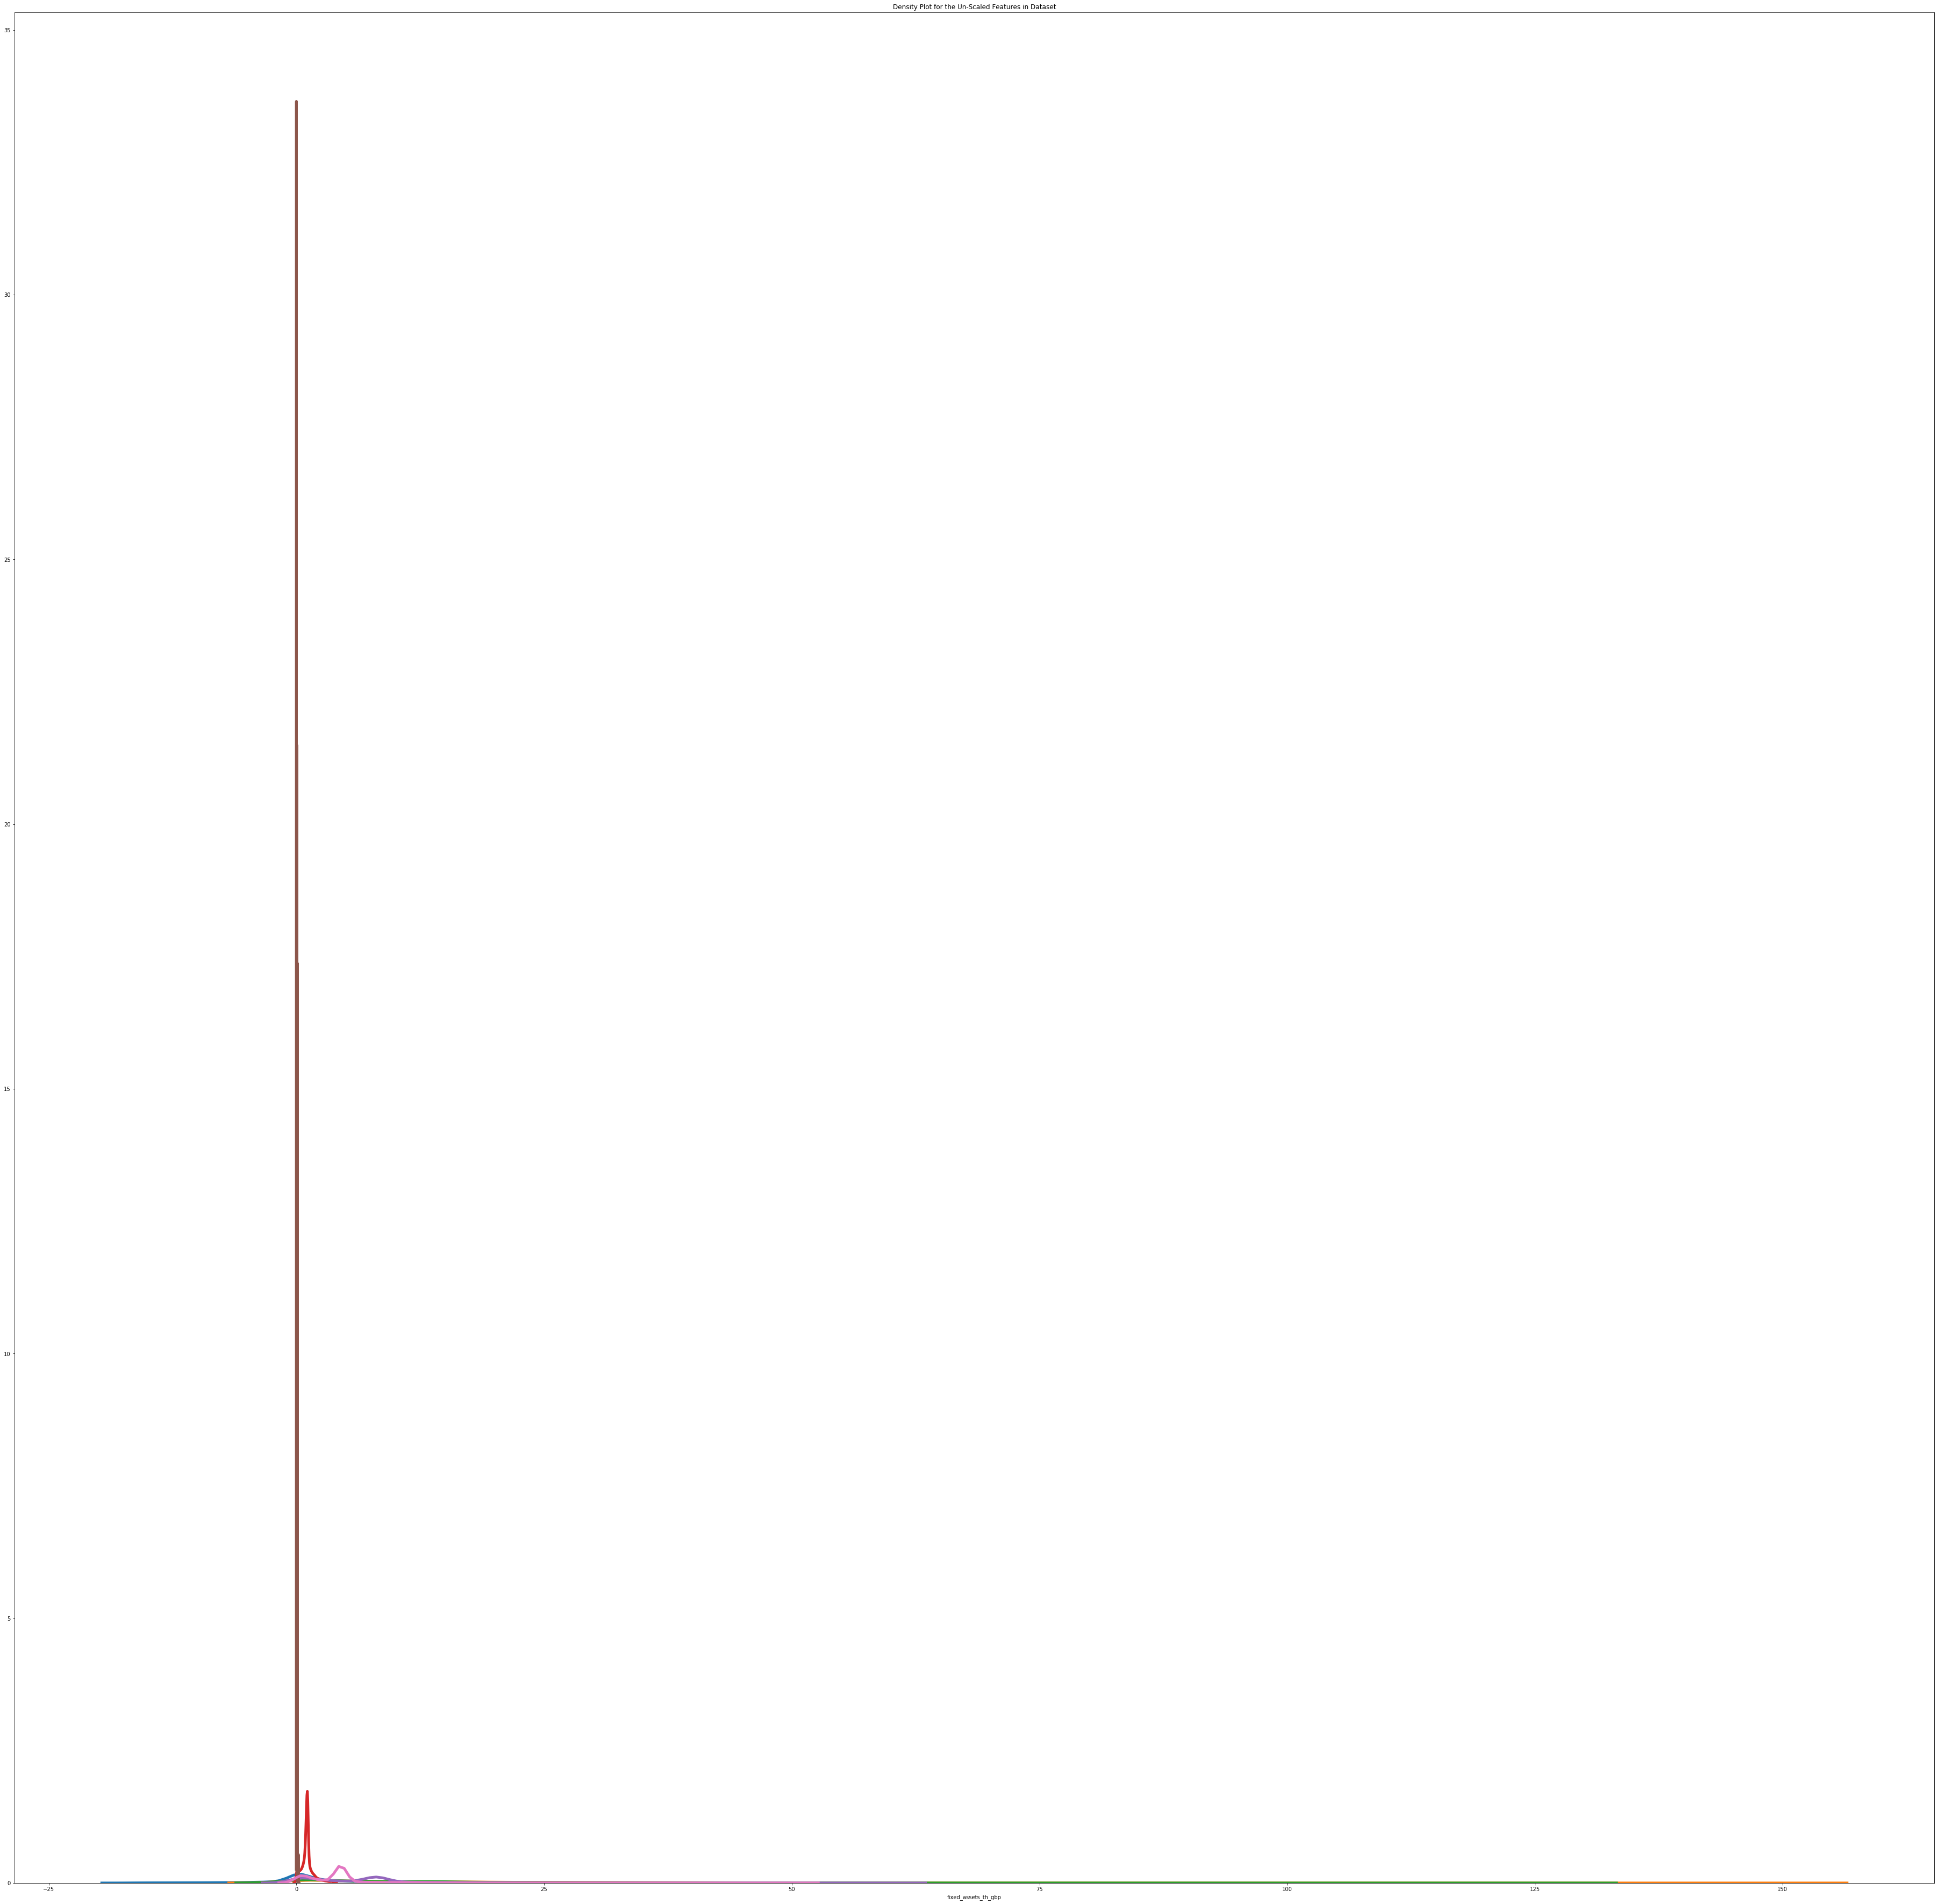

In [25]:
plt.figure(figsize=(64,64))
plt.title('Density Plot for the Un-Scaled Features in Dataset')
for c in df4.columns[0:19:3]:
    # Draw the density plot
    sb.distplot(df4[c], hist = False, kde = True,
                 kde_kws = {'linewidth': 5})

In [26]:
X_test = df4.sample(frac=0.20, replace=True, random_state=1)
Y_test = Y_.loc[X_test.index]
Y_test

50657    False
358      False
20308    False
8819     False
28940    False
         ...  
10812    False
47988    False
14993    False
12506    False
11883     True
Name: UP_solvency_ratio_(asset_based)_(%), Length: 6460, dtype: bool

In [29]:
X_train = df4.drop(X_test.index)
Y_train = Y_.loc[X_train.index]
X_train.shape

(26452, 20)

In [30]:
Y_train.head()

0    False
1     True
2     True
3    False
5     True
Name: UP_solvency_ratio_(asset_based)_(%), dtype: bool

In [31]:
Y_train.shape

(26452,)

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_trn = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=X_train.columns)
X_tst = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
print("X_trn shape: ",X_trn.shape)
print("X_tst shape: ",X_tst.shape)

X_trn shape:  (26452, 20)
X_tst shape:  (6460, 20)


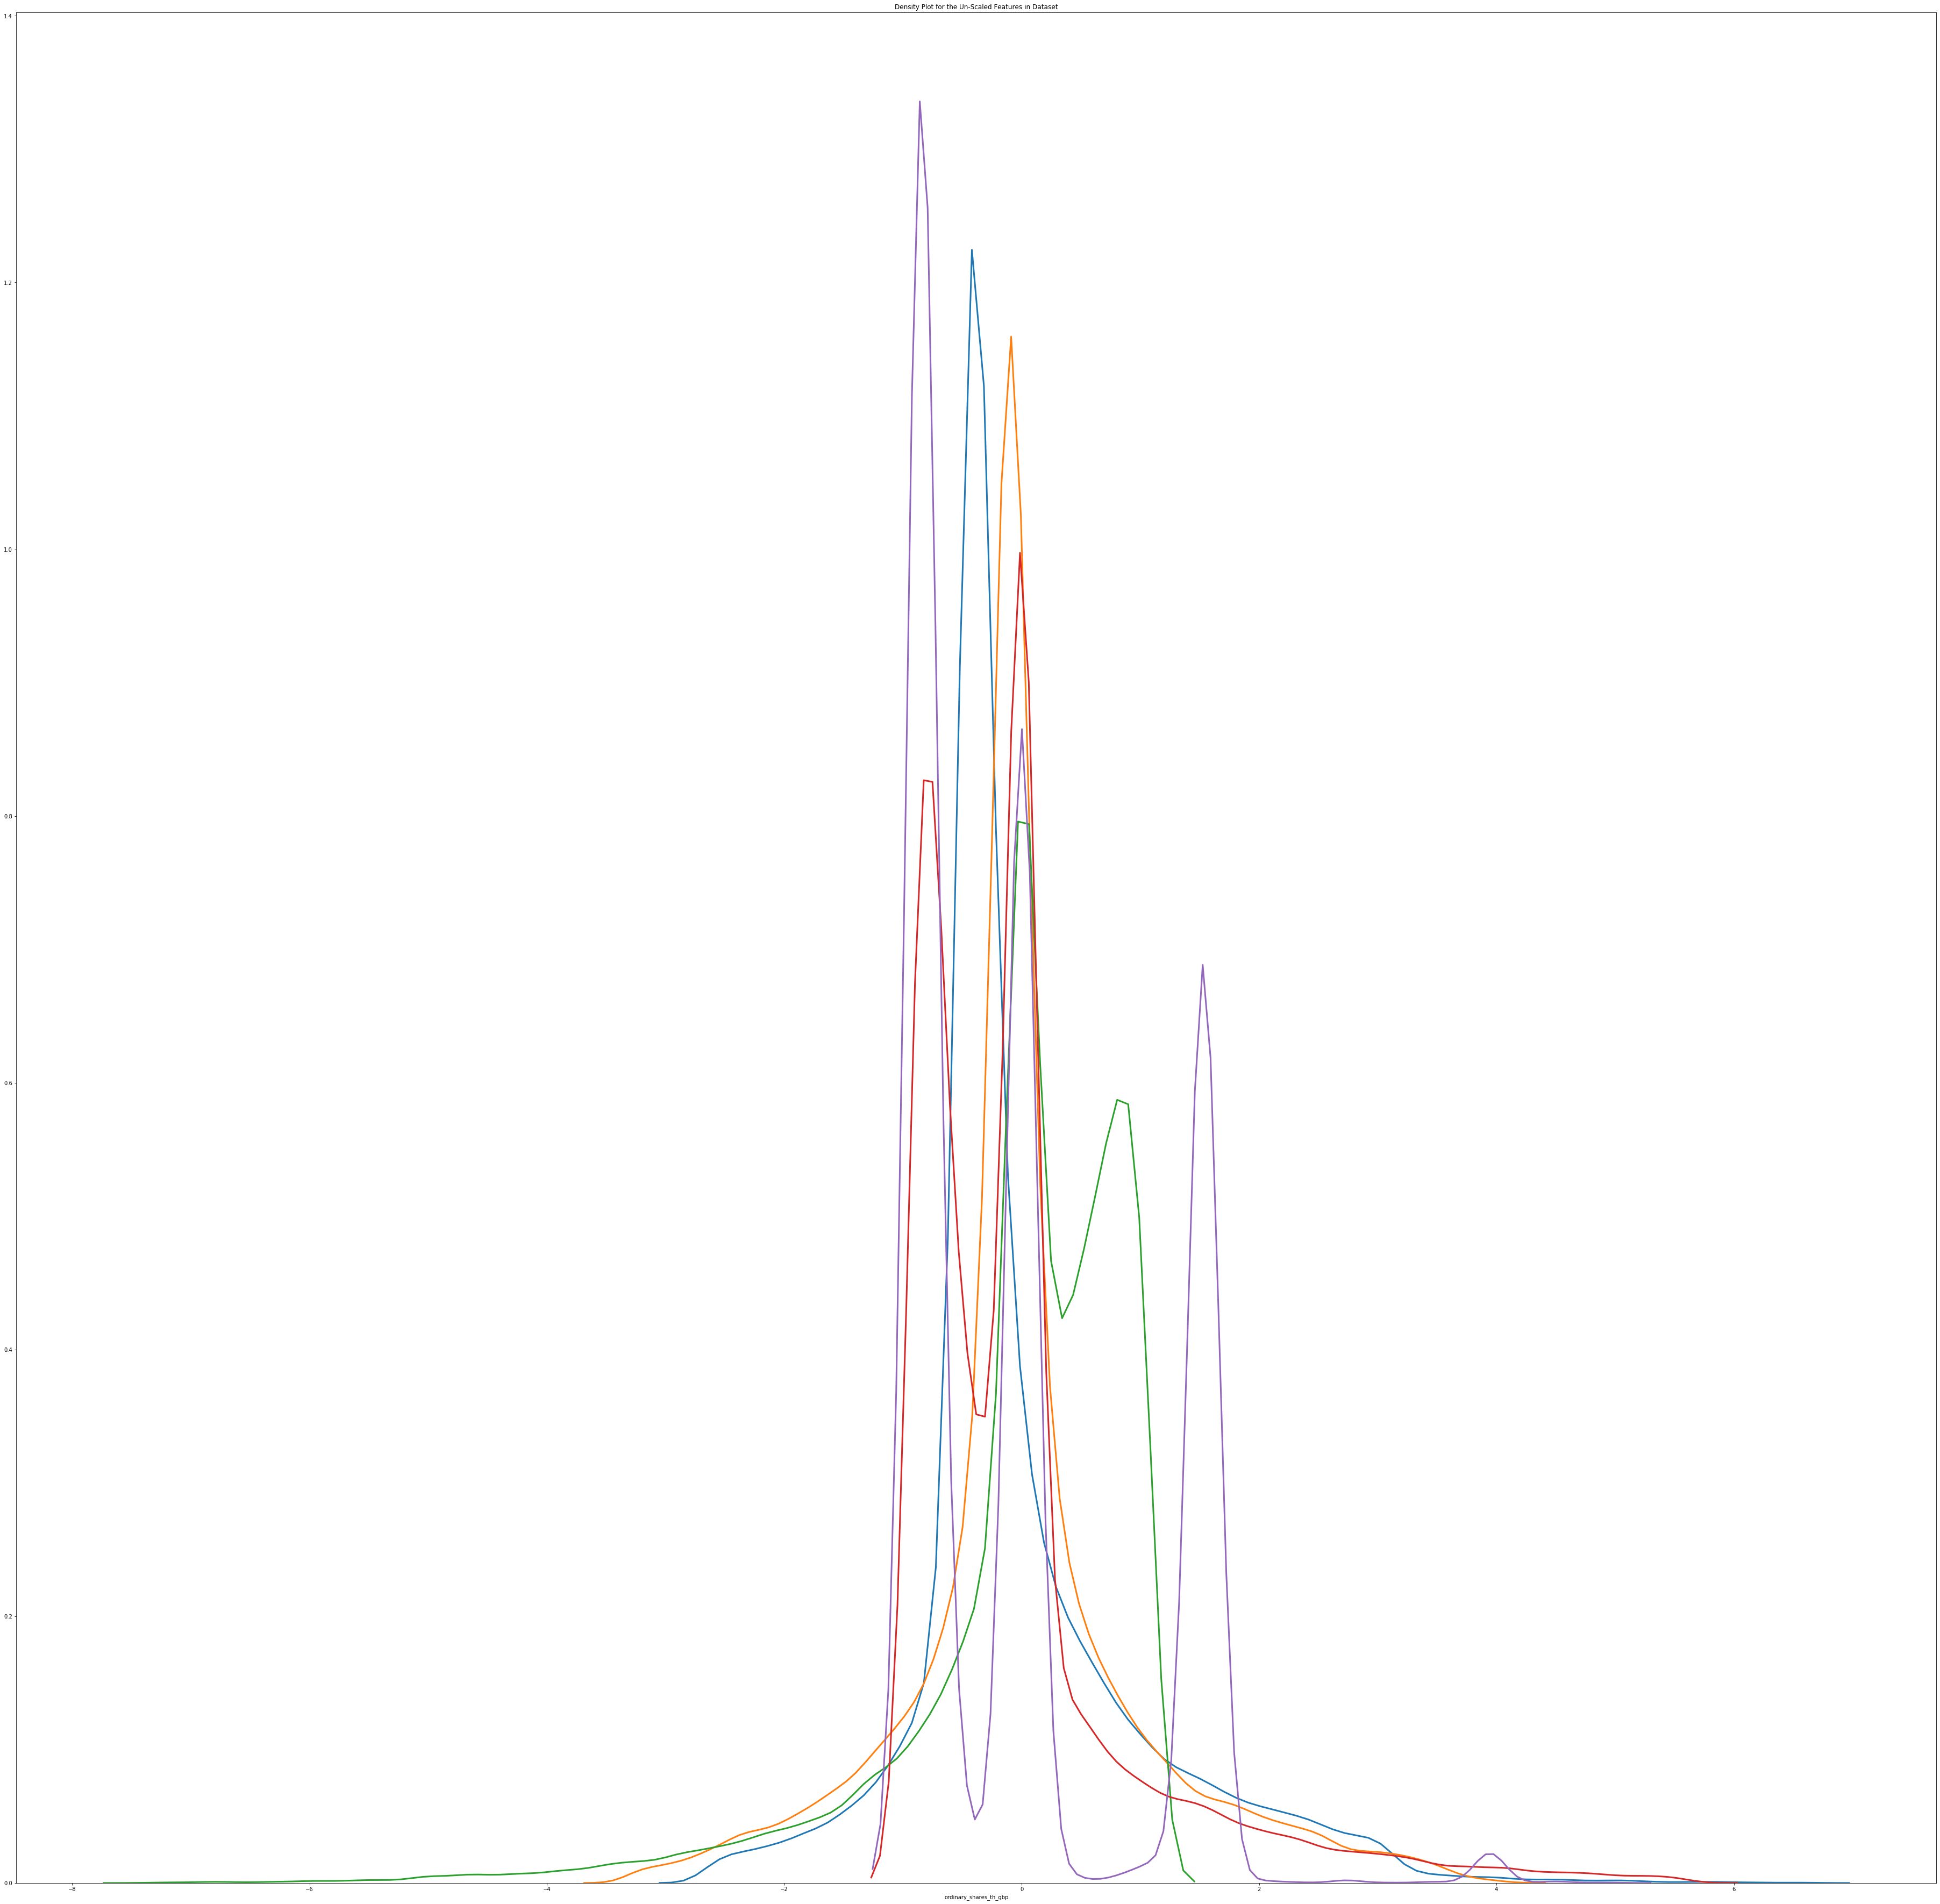

In [33]:
plt.figure(figsize=(64,64))
plt.title('Density Plot for the Un-Scaled Features in Dataset')
for c in X_trn.columns[0:19:4]:
    # Draw the density plot
    sb.distplot(X_trn[c], hist = False, kde = True,
                 kde_kws = {'linewidth': 3})

In [34]:
from sklearn.preprocessing import LabelBinarizer
lb=LabelBinarizer()
y_train_one_hot = lb.fit_transform(Y_train)
y_test_one_hot = lb.transform(Y_test)

print('Train labels dimension:');print(y_train_one_hot.shape)
print('Test labels dimension:');print(y_test_one_hot.shape)
print(y_train_one_hot[100])
print(y_train_one_hot[10])
print(y_train_one_hot[1])

Train labels dimension:
(26452, 1)
Test labels dimension:
(6460, 1)
[0]
[1]
[1]


In [35]:
import os
os.environ["KERAS_BACKEND"] = "plaidml.keras.backend"
import keras
from keras.models import Sequential
from keras.layers import Dense

Using plaidml.keras.backend backend.


In [39]:
num_classes = y_train_one_hot.shape[1]; num_features = X_trn.shape[1]
#X_tst
num_layers_0 = 16; num_layers_1 = 8
# Define the keras model
model = Sequential()
model.add(Dense(num_layers_0, input_dim=num_features, activation='relu'))
model.add(Dense(num_layers_1, activation='relu'))
model.add(Dense(num_classes, activation='sigmoid'))
from keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
class MetricsCheckpoint(Callback):
    """Callback that saves metrics after each epoch"""
    def __init__(self, savepath):
        super(MetricsCheckpoint, self).__init__()
        self.savepath = savepath
        self.history = {}
    def on_epoch_end(self, epoch, logs=None):
        for k, v in logs.items():
            self.history.setdefault(k, []).append(v)
        np.save(self.savepath, self.history)


# Compile the keras model
#model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])
model.compile(loss='binary_crossentropy', 
                 optimizer='adam',
                 metrics=['accuracy'])
filepath="weights-improvement-{epoch:02d}-{loss:.4f}-FafnirMLPClassifier.hdf5"
weights_improvement = ModelCheckpoint(filepath, monitor='acc', verbose=1, save_best_only=True, mode='max')
callbacks_list = [keras.callbacks.EarlyStopping(monitor='acc', patience=3, verbose=1),weights_improvement]
model.summary()
# Fit keras model


_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_7 (Dense)              (None, 16)                336       
_________________________________________________________________
dense_8 (Dense)              (None, 8)                 136       
_________________________________________________________________
dense_9 (Dense)              (None, 1)                 9         
Total params: 481
Trainable params: 481
Non-trainable params: 0
_________________________________________________________________


In [40]:

from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='acc', patience=10, restore_best_weights=True)
history = model.fit(X_trn,y_train_one_hot, epochs=512, verbose=1,callbacks = [MetricsCheckpoint('logs'),early_stopping])
#history = model.fit(X_train, y_train_one_hot, epochs=512, batch_size=8, validation_split = 0.30)



Epoch 1/512
26452/26452 [==============================] - 4s 156us/step - loss: 0.6289 - acc: 0.6279
Epoch 2/512
26452/26452 [==============================] - 4s 146us/step - loss: 0.5788 - acc: 0.6436
Epoch 3/512
26452/26452 [==============================] - 4s 149us/step - loss: 0.5657 - acc: 0.6545
Epoch 4/512
26452/26452 [==============================] - 4s 149us/step - loss: 0.5582 - acc: 0.6597
Epoch 5/512
26452/26452 [==============================] - 4s 141us/step - loss: 0.5537 - acc: 0.6607
Epoch 6/512
26452/26452 [==============================] - 4s 137us/step - loss: 0.5495 - acc: 0.6644
Epoch 7/512
26452/26452 [==============================] - 3s 131us/step - loss: 0.5469 - acc: 0.6653
Epoch 8/512
26452/26452 [==============================] - 4s 141us/step - loss: 0.5445 - acc: 0.6669
Epoch 9/512
26452/26452 [==============================] - 4s 136us/step - loss: 0.5426 - acc: 0.6679
Epoch 10/512
26452/26452 [==============================] - 4s 134us/step - loss: 

In [61]:
from pprint import pprint
import sklearn
from sklearn.metrics import confusion_matrix
def training_report(model,history,xtest,ytest,labels={0: 'No Growth', 1: 'Yes Growth'}):
    # Evaluate model
    score = model.evaluate(xtest,ytest, verbose=0)
    print('\nKeras - accuracy:', score[1], '\n')
    pprint(score)
    y_pred = model.predict(xtest)
    #print('\n', sklearn.metrics.classification_report(np.where(ytest > 0)[1], np.argmax(y_pred, axis=1), target_names=list(labels.values())), sep='') 
    Y_pred_classes = np.argmax(y_pred,axis = 1) 
    Y_true = np.argmax(ytest,axis = 1) 
    confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)
    plotKerasLearningCurve()
    plt.show()
    plot_learning_curve(history)
    plt.show()
    plot_confusion_matrix(confusion_mtx, classes = list(labels.values()))
    plt.show()

def plotKerasLearningCurve():
    plt.figure(figsize=(10,5))
    metrics = np.load('logs.npy',allow_pickle=True)[()]
    filt = ['loss'] # try to add 'loss' to see the loss learning curve
    for k in filter(lambda x : np.any([kk in x for kk in filt]), metrics.keys()):
        l = np.array(metrics[k])
        plt.plot(l, c= 'r' if 'val' not in k else 'b', label='val' if 'val' in k else 'train')
        x = np.argmin(l) if 'loss' in k else np.argmax(l)
        y = l[x]
        plt.scatter(x,y, lw=0, alpha=0.25, s=100, c='r' if 'val' not in k else 'b')
        plt.text(x, y, '{} = {:.4f}'.format(x,y), size='15', color= 'r' if 'val' not in k else 'b')   
    plt.legend(loc=4)
    plt.axis([0, None, None, None]);
    plt.grid()
    plt.xlabel('Number of epochs')
    plt.ylabel('Accuracy')

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize = (5,5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

def plot_learning_curve(history):
    plt.figure(figsize=(16,6))
    plt.subplot(1,2,1)
    plt.plot(history.history['acc'])
    plt.plot(history.history['loss'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.savefig('./accuracy_curve.png')
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.savefig('./loss_curve.png')

In [64]:
history.history.keys()

dict_keys(['loss', 'acc'])


Keras - accuracy: 0.6710526317634818 

[0.5284680270558171, 0.6710526317634818]


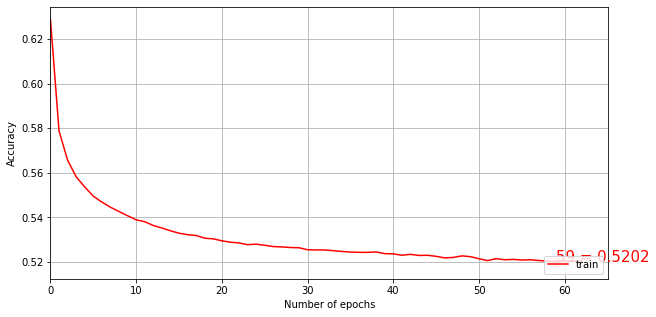

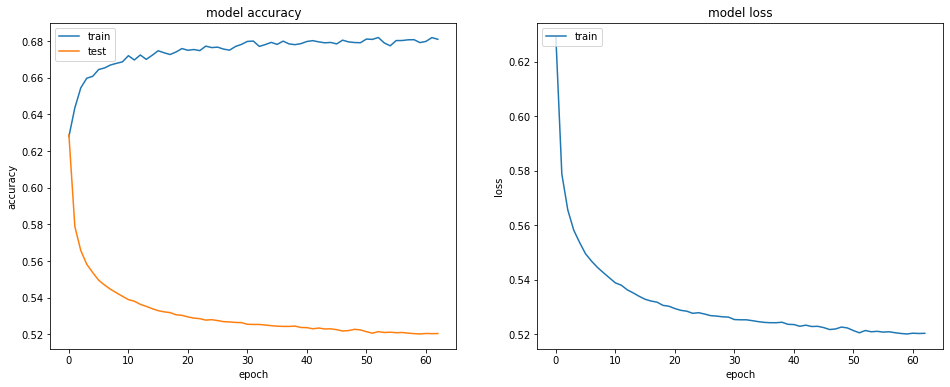

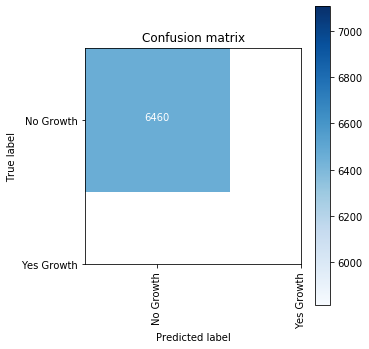

ValueError: x and y must have same first dimension, but have shapes (3,) and (63,)

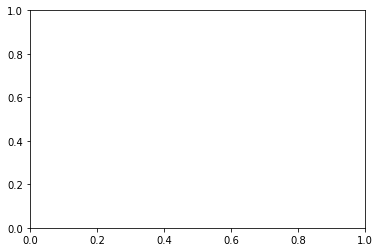

In [65]:
import itertools
training_report(model, history, X_tst, y_test_one_hot)
loss = history.history['loss']
acc = history.history['acc']
epochs = range(3)
plt.figure()
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, acc, 'r', label='Validation acc')
plt.title('Training and validation loss')
plt.legend()
plt.show()